# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Daffa Aufa Afif | 5054251022|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd # Menyipan datanya nanti
import numpy as np # kalkulasi math
import matplotlib.pyplot as plt # visualisasi
import seaborn as sns # visualisasi2
import os # buat api kaggle
from google.colab import files
from dotenv import load_dotenv
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,roc_curve, roc_auc_score


In [2]:
# Upload the api.txt file
uploaded = files.upload()

# Check if the file was uploaded
if 'api.txt' in uploaded:
    # Create the .env directory if it doesn't exist
    env_dir = './.env'
    if not os.path.exists(env_dir):
        os.makedirs(env_dir)

    # Move the uploaded file to the .env directory
    with open(os.path.join(env_dir, 'api.txt'), 'wb') as f:
        f.write(uploaded['api.txt'])
    print("api.txt uploaded and moved to .env/api.txt")

    # Delete the original api.txt file from the current directory
    os.remove('api.txt')
else:
    print("api.txt was not uploaded.")

Saving api.txt to api.txt
api.txt uploaded and moved to .env/api.txt


In [3]:
# Load the environment variables from the .env file
load_dotenv('./.env/api.txt')

# Verify the credentials were read successfully
if os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'):
    print("Kaggle credentials loaded successfully from .env file!")
    print("Kaggle Username:", os.environ.get('KAGGLE_USERNAME'))
else:
    print("Failed to load credentials. check your variable names.")


Kaggle credentials loaded successfully from .env file!
Kaggle Username: daffaaufaafif


In [4]:
# Replace with your actual Kaggle dataset command
# Create a data folder (the -p flag ensures it won't crash if the folder already exists)
!mkdir -p data
#  Download the dataset directly into the data folder using the -p flag
!kaggle datasets download uciml/mushroom-classification -p data

# Unzip the downloaded files
!unzip data/*.zip -d data
!rm data/*.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/mushroom-classification
License(s): CC0-1.0
100% 34.2k/34.2k [00:00<00:00, 50.6MB/s]

Archive:  data/mushroom-classification.zip
  inflating: data/mushrooms.csv      


In [35]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
df = pd.read_csv('data/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [36]:
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [37]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
print(df.shape)
print(df.info())
df = df.replace("?", np.nan)
print(df.isna().sum())

(8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-a

In [38]:
"""
About this file

Attribute Information: (classes: edible=e, poisonous=p)

    cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

    cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s

    cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

    bruises: bruises=t,no=f

    odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

    gill-attachment: attached=a,descending=d,free=f,notched=n

    gill-spacing: close=c,crowded=w,distant=d

    gill-size: broad=b,narrow=n

    gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

    stalk-shape: enlarging=e,tapering=t

    stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?

    stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s

    stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s

    stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

    stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

    veil-type: partial=p,universal=u

    veil-color: brown=n,orange=o,white=w,yellow=y

    ring-number: none=n,one=o,two=t

    ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

    spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

    population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

    habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

"""
mappin = {
    'class': {'e': 0, 'p': 1},
    'cap-shape': {'b': 0, 'c': 1, 'x': 2, 'f': 3, 'k': 4, 's': 5},
    'cap-surface': {'f': 0, 'g': 1, 'y': 2, 's': 3},
    'cap-color': {'n': 0, 'b': 1, 'c': 2, 'g': 3, 'r': 4, 'p': 5, 'u': 6, 'e': 7, 'w': 8, 'y': 9},
    'bruises': {'t': 0, 'f': 1},
    'odor': {'a': 0, 'l': 1, 'c': 2, 'y': 3, 'f': 4, 'm': 5, 'n': 6, 'p': 7, 's':8},
    'gill-attachment':{'a': 0, 'd': 1, 'f': 2, 'n': 3},
    'gill-spacing': {'c': 0, 'w': 1, 'd': 2},
    'gill-size': {'b': 0, 'n': 1},
    'gill-color': {'k': 0, 'n': 1, 'b': 2, 'h': 3, 'g': 4, 'r': 5, 'o': 6, 'p':7, 'u': 8, 'e': 9, 'w': 10, 'y': 11},
    'stalk-shape': {'e': 0, 't': 1},
    'stalk-root': {'b': 0, 'c': 1, 'u': 2, 'e': 3, 'z': 4, 'r': 5, '?': 6},
    'stalk-surface-above-ring': {'f': 0, 'y': 1, 'k': 2, 's': 3},
    'stalk-surface-below-ring': {'f': 0, 'y': 1, 'k': 2, 's': 3},
    'stalk-color-above-ring': {'n': 0, 'b': 1, 'c': 2, 'g': 3, 'o': 4, 'p': 5, 'e': 6, 'w': 7, 'y':8},
    'stalk-color-below-ring': {'n': 0, 'b': 1, 'c': 2, 'g': 3, 'o': 4, 'p': 5, 'e': 6, 'w': 7, 'y':8},
    'veil-type': {'p': 0, 'u': 1},
    'veil-color': {'n': 0, 'o': 1, 'w': 2, 'y': 3},
    'ring-number': {'n': 0, 'o': 1, 't': 2},
    'ring-type': {'c': 0, 'e': 1, 'f': 2, 'l': 3, 'n': 4, 'p': 5, 's': 6, 'z': 7},
    'spore-print-color': {'k': 0, 'n': 1, 'b': 2, 'h': 3, 'r': 4, 'o': 5, 'u': 6, 'w': 7, 'y':8},
    'population': {'a': 0, 'c': 1, 'n': 2, 's': 3, 'v': 4, 'y': 5},
    'habitat': {'g': 0, 'l': 1, 'm': 2, 'p': 3, 'u': 4, 'w': 5, 'd': 6}
}


In [39]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
for i in df.columns:
  print( df[i].value_counts(dropna=False), end="\n \n")

class
e    4208
p    3916
Name: count, dtype: int64
 
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64
 
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64
 
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64
 
bruises
f    4748
t    3376
Name: count, dtype: int64
 
odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64
 
gill-attachment
f    7914
a     210
Name: count, dtype: int64
 
gill-spacing
c    6812
w    1312
Name: count, dtype: int64
 
gill-size
b    5612
n    2512
Name: count, dtype: int64
 
gill-color
b    1728
p    1492
w    1202
n    1048
g     752
h     732
u     492
k     408
e      96
y      86
o      64
r      24
Name: count, dtype: int64
 
stalk-shape
t    4608
e    3516
Name: count, dtype: int64
 
stalk-root
b      3776
NaN    2480
e      1120
c 

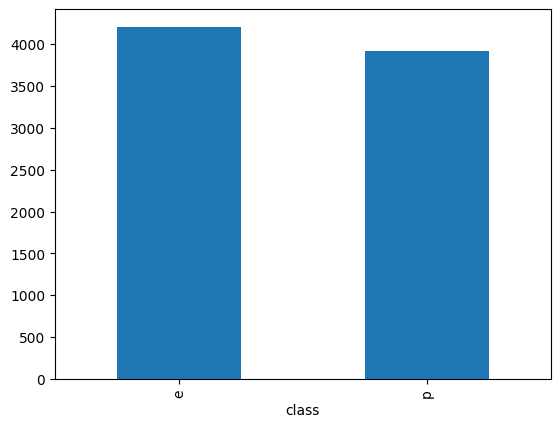

Selisih:  292
Selisih Percent: 3.59 %


/tmp/ipykernel_2286/3506852536.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  _dif = df['class'].value_counts()[0] - df['class'].value_counts()[1]
/tmp/ipykernel_2286/3506852536.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  _dif = df['class'].value_counts()[0] - df['class'].value_counts()[1]


In [40]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
df['class'].value_counts().plot(kind='bar')
plt.show()
# e =edible, p=poisonous
_dif = df['class'].value_counts()[0] - df['class'].value_counts()[1]
print("Selisih: ", _dif)
print("Selisih Percent:", round(_dif / len(df) * 100,2),"%")

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [41]:
df_changed = df.replace(mappin)

/tmp/ipykernel_2286/4196805367.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_changed = df.replace(mappin)


In [42]:
df_changed = df_changed.drop(columns=['veil-type']) # karena datanya sejenis

In [43]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Hitung Cramér's V untuk setiap fitur terhadap 'class'
results = {}
for col in df_changed.columns:
    if col != 'class':
        results[col] = cramers_v(df[col], df['class'])

# Urutkan dari yang paling efektif
cramer_df = pd.Series(results).sort_values(ascending=False)
print("Ranking Efektivitas Fitur (Cramér's V):")
print(cramer_df)


Ranking Efektivitas Fitur (Cramér's V):
odor                        0.971005
spore-print-color           0.752645
gill-color                  0.680830
ring-type                   0.603271
stalk-surface-above-ring    0.587944
stalk-surface-below-ring    0.574837
gill-size                   0.539758
stalk-color-above-ring      0.524850
stalk-color-below-ring      0.514725
bruises                     0.501280
population                  0.487376
habitat                     0.440136
gill-spacing                0.348052
stalk-root                  0.336284
cap-shape                   0.245571
cap-color                   0.218427
ring-number                 0.214772
cap-surface                 0.196925
veil-color                  0.153421
gill-attachment             0.128424
stalk-shape                 0.101770
dtype: float64


Dari Cramer V, dapat diambil kesimpulan bahwa `odor` memiliki tingkat efektivitas tertinggi, mendekati 1.
Selanjutnya, akan diambil 6 fitur teratas yaitu: `["odor","spore-print-clor","gill-color","ring-type","stalk-surface-above-ring","stalk-surface-below-ring]`
Dari keenam fitur tersebut akan dilakukan pengecekan keterhubungan antar fitur dengan chi square dan cramer's V


In [44]:
focus = ["odor","spore-print-color","gill-color","ring-type","stalk-surface-above-ring","stalk-surface-below-ring"]

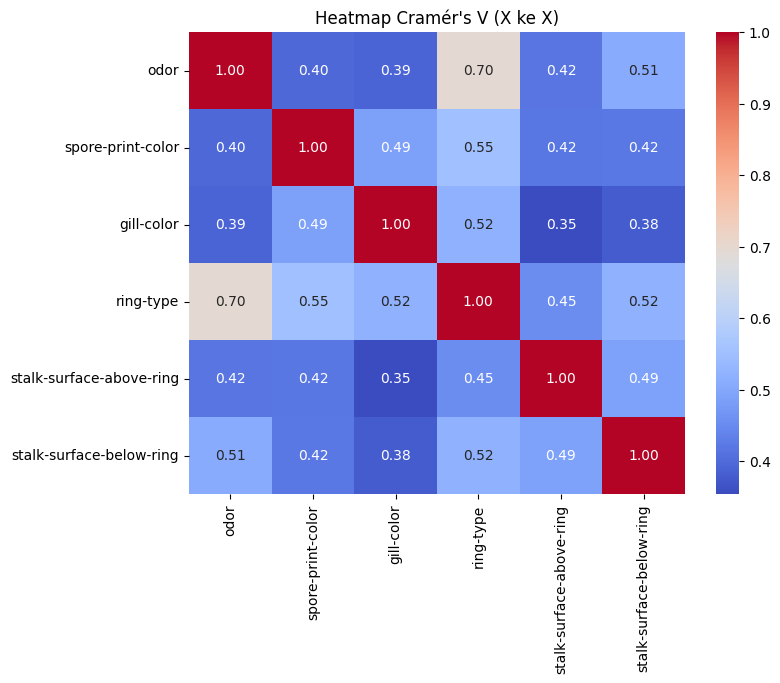

In [45]:
res = {}
for col in focus:
    res[col] = {smt: cramers_v(df[col], df[smt]) for smt in focus}

cramer_df = pd.DataFrame(res)
plt.figure(figsize=(8, 6))
sns.heatmap(cramer_df, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap Cramér's V (X ke X)")
plt.show()

Terlihat bahwa `odor` dan `ring-type` memiliki keterkaitan yang cukup tinggi($0.7$). Selain itu, `ring-type` keefektifannya terhadap identifikasi `class` hanyalah $0.6$, maka lebih baik di-drop

In [46]:
if "ring-type" in focus:
  focus.remove("ring-type")
print(focus)

['odor', 'spore-print-color', 'gill-color', 'stalk-surface-above-ring', 'stalk-surface-below-ring']


Selanjutnya cek frekuensi kemunculan untuk fitur-fitur pilihan

In [47]:
for col in focus:
    print(f"=== Frekuensi Kategori Kolom: {col} ===")

    # Hitung jumlah dan persentase
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    freq_df = pd.DataFrame({'Jumlah': counts, 'Persentase (%)': percentages.round(2)})
    print(freq_df)

    possible_keys = list(mappin[col].keys())
    existing_keys = list(df[col].unique())
    # Nyari data yang kelewat dari mapping
    missing_in_data = set(possible_keys) - set(existing_keys)

    if missing_in_data:
        print(f"--> Kategori di metadata tapi 0 di data: {missing_in_data}")

    # Cek jika ada kategori langka
    rare = freq_df[freq_df['Persentase (%)'] < 1.0].index.tolist()
    if rare:
        print(f"--> Kategori Langka (< 1%): {rare}")

    print("-" * 50 + "\n")

=== Frekuensi Kategori Kolom: odor ===
      Jumlah  Persentase (%)
odor                        
n       3528           43.43
f       2160           26.59
s        576            7.09
y        576            7.09
a        400            4.92
l        400            4.92
p        256            3.15
c        192            2.36
m         36            0.44
--> Kategori Langka (< 1%): ['m']
--------------------------------------------------

=== Frekuensi Kategori Kolom: spore-print-color ===
                   Jumlah  Persentase (%)
spore-print-color                        
w                    2388           29.39
n                    1968           24.22
k                    1872           23.04
h                    1632           20.09
r                      72            0.89
u                      48            0.59
o                      48            0.59
y                      48            0.59
b                      48            0.59
--> Kategori Langka (< 1%): ['r', 'u', 'o'

Diketahui pada fitur yang akan dipakai, tidak ada NaN atau '?'. Didapati juga beberapa value/kategori langka yaitu: `{"odor":['m'], "spore-printcolor":['r', 'u', 'o', 'y', 'b'], "gill-color":['o','r'],stalk-surface-above-ring:['y']}`

Naive bayes sendiri cukup sensitif dengan fitur dengan kategori yang sangat *diverse*, maka kategori langka akan dihilangkan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [48]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.


Diawal, nilai '?' telah diubah menjadi `Nan`, Penghapusan dapat dilakukan dengan `.dropna`. Tetapi, tidak dilakukan karena fitur yang memiliki nilai tersebut tidak akan dipakai pada training. Selain itu, penghapusan baris yang memiliki '?' atau Nan(setelah diubah) berpotensi merusak hasil akhir.

In [49]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

df = df.drop(columns=["veil-type"],axis=1)
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,s,w,w,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,s,o,o,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,s,o,o,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,s,o,o,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,s,k,w,w,w,o,e,w,v,l


In [50]:
used_df = df[focus+["class"]].copy()
used_df

,odor,spore-print-color,gill-color,stalk-surface-above-ring,stalk-surface-below-ring,class
0,p,k,k,s,s,p
1,a,n,k,s,s,e
2,l,n,n,s,s,e
3,p,k,n,s,s,p
4,n,n,k,s,s,e
...,...,...,...,...,...,...
8119,n,b,y,s,s,e
8120,n,b,y,s,s,e
8121,n,b,n,s,s,e
8122,y,w,b,s,k,p


In [51]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
# Terapkan reduksi kategori langka setelah train_test_split

X = used_df[focus]

# 3. Encode target: 'e' -> 0, 'p' -> 1
y = used_df["class"].map({"e": 0, "p": 1})

# 4. Split data (80:20) dengan stratifikasi pada target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cek dimensi data hasil split
print(f"Jumlah sampel Train: {X_train.shape[0]} baris")
print(f"Jumlah sampel Test : {X_test.shape[0]} baris")
print("\nProporsi Kelas y_train:")
print(y_train.value_counts(normalize=True).round(4))

Jumlah sampel Train: 6499 baris
Jumlah sampel Test : 1625 baris

Proporsi Kelas y_train:
class
0    0.5179
1    0.4821
Name: proportion, dtype: float64


In [52]:
X_train = X_train.copy()
X_test = X_test.copy()

threshold = 0.01  # Batas 1%
rare_dict_dynamic = {}

for col in X_train.columns:
    # Hitung persentase frekuensi HANYA di X_train
    freq = X_train[col].value_counts(normalize=True)

    # Ambil kategori yang persentasenya di bawah threshold (1%)
    rare_values = freq[freq < threshold].index.tolist()

    if rare_values:
        rare_dict_dynamic[col] = rare_values
        # Terapkan transformasi ke X_train dan X_test memakai aturan dari X_train
        X_train[col] = X_train[col].replace(rare_values, 'Other')
        X_test[col] = X_test[col].replace(rare_values, 'Other')

print("Daftar kategori langka yang terdeteksi di X_train:")
print(rare_dict_dynamic)
print("\nPembersihan kategori langka selesai!\n")

Daftar kategori langka yang terdeteksi di X_train:
{'odor': ['m'], 'spore-print-color': ['r', 'y', 'o', 'b', 'u'], 'gill-color': ['o', 'r'], 'stalk-surface-above-ring': ['y']}

Pembersihan kategori langka selesai!



In [53]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
# Gunakan OrdinalEncoder untuk merubah setiap kategori menjadi integer
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Fit hanya pada train set, transform pada train set dan test set
X_train_cat = oe.fit_transform(X_train)
X_test_cat = oe.transform(X_test)

print(f"Bentuk data Ordinal (CategoricalNB): {X_train_cat.shape}")

Bentuk data Ordinal (CategoricalNB): (6499, 5)


Perubahan menjadi int sudah dari awal EDA

In [54]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

# Fit hanya pada train set, transform pada train set dan test set
X_train_ohe = ohe.fit_transform(X_train)
X_test_ohe = ohe.transform(X_test)

print(f"Bentuk data One-Hot (Bernoulli/Multi): {X_train_ohe.shape}")

Bentuk data One-Hot (Bernoulli/Multi): (6499, 33)


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [55]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.

cat_nb = CategoricalNB(alpha=1.0)
cat_nb.fit(X_train_cat, y_train)

CategoricalNB()

In [56]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
# Inisialisasi dictionary penyimpan hasil jika variabel belum dibuat
if 'eval_results' not in locals():
    eval_results = {}

# Prediksi label dan probabilitas untuk kelas 1 (poisonous)
y_pred_cat = cat_nb.predict(X_test_cat)
y_proba_cat = cat_nb.predict_proba(X_test_cat)[:, 1]

# Simpan hasil ke dictionary global
eval_results['Categorical NB'] = {
    'y_pred': y_pred_cat,
    'y_proba': y_proba_cat
}

print("Prediksi Categorical NB berhasil disimpan ke variabel 'eval_results'.")

Prediksi Categorical NB berhasil disimpan ke variabel 'eval_results'.


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [57]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.

bernoulli_nb = BernoulliNB(alpha=1.0)
bernoulli_nb.fit(X_train_ohe, y_train)

BernoulliNB()

In [58]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bernoulli = bernoulli_nb.predict(X_test_ohe)
y_proba_bernoulli = bernoulli_nb.predict_proba(X_test_ohe)[:, 1]

# Simpan hasil ke dictionary global
eval_results['Bernoulli NB'] = {
    'y_pred': y_pred_bernoulli,
    'y_proba': y_proba_bernoulli
}

print("Prediksi Bernoulli NB berhasil disimpan ke variabel 'eval_results'.")

Prediksi Bernoulli NB berhasil disimpan ke variabel 'eval_results'.


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [59]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
multinomial_nb = MultinomialNB(alpha=1.0)
multinomial_nb.fit(X_train_ohe, y_train)

MultinomialNB()

In [60]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_multi = multinomial_nb.predict(X_test_ohe)
y_proba_multi = multinomial_nb.predict_proba(X_test_ohe)[:, 1]

# Simpan hasil ke dictionary global
eval_results['Multinomial NB'] = {
    'y_pred': y_pred_multi,
    'y_proba': y_proba_multi
}

print("Prediksi Multinomial NB berhasil disimpan ke variabel 'eval_results'.")

Prediksi Multinomial NB berhasil disimpan ke variabel 'eval_results'.


# 4. Evaluasi Model

In [61]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
metrics_summary = []
best = {'model':None, 'rec':-1}
for model_name, data in eval_results.items():
    y_pred = data['y_pred']

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    metrics_summary.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })
    if rec > best['rec']:
        best['model'] = model_name
        best['rec'] = rec

# Buat DataFrame perbandingan dan format tampilan 4 angka di belakang koma
print("Model terbaik(berdasarkan recall): ",best["model"])
df_comparison = pd.DataFrame(metrics_summary).set_index('Model')
print("Tabel Perbandingan Evaluasi Model Naive Bayes:")
df_comparison.style.format("{:.5f}")


Model terbaik(berdasarkan recall):  Categorical NB
Tabel Perbandingan Evaluasi Model Naive Bayes:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Categorical NB,0.93600,0.96571,0.89911,0.93122
Bernoulli NB,0.92492,0.96484,0.87612,0.91834
Multinomial NB,0.93600,0.96571,0.89911,0.93122


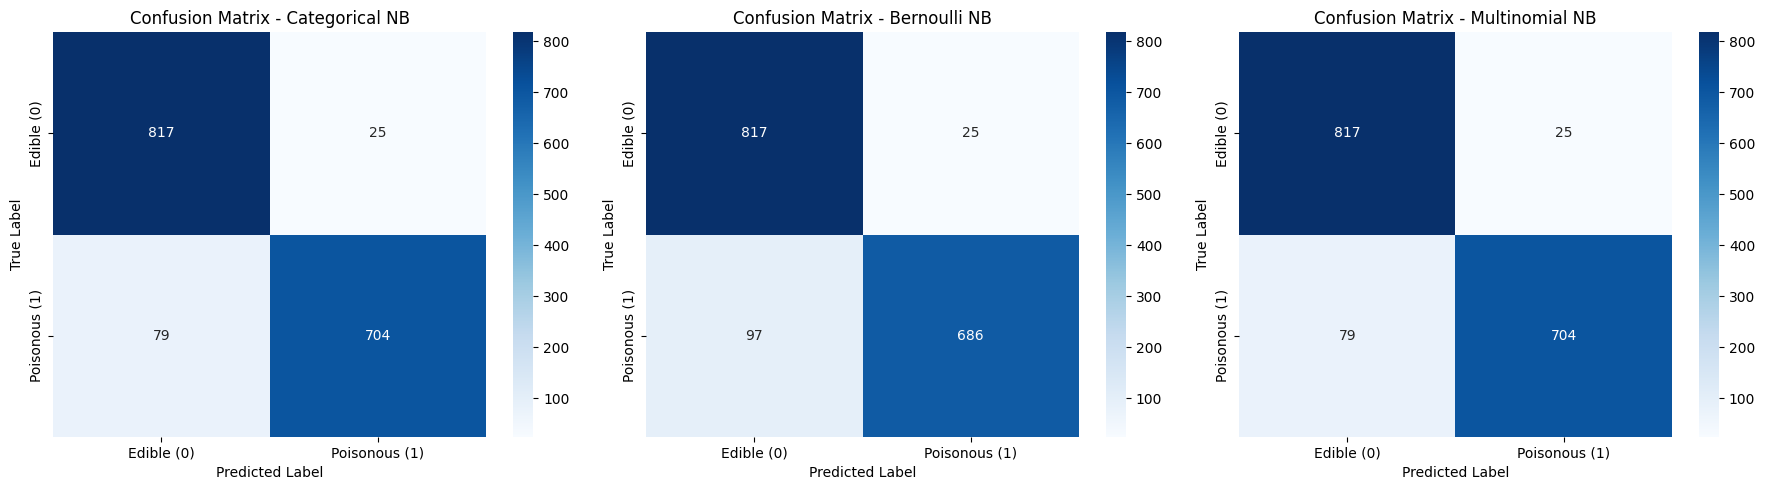

In [62]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, data) in zip(axes, eval_results.items()):
    cm = confusion_matrix(y_test, data['y_pred'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Edible (0)', 'Poisonous (1)'],
        yticklabels=['Edible (0)', 'Poisonous (1)']
    )

    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

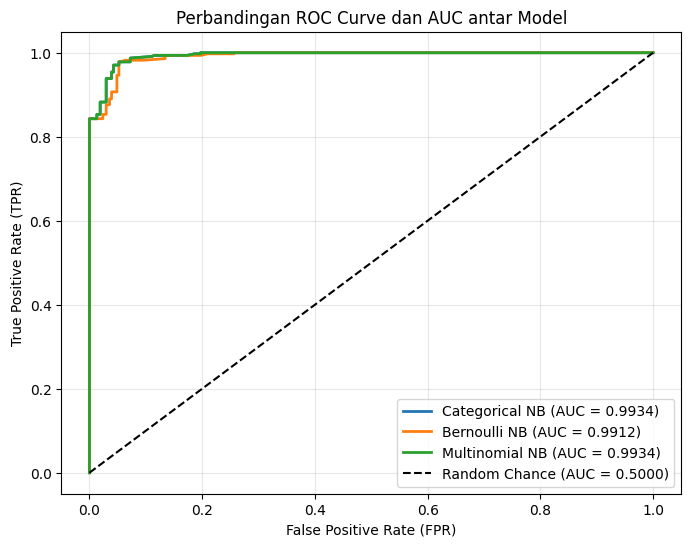

In [63]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(8, 6))
for model_name, data in eval_results.items():
    fpr, tpr, _ = roc_curve(y_test, data['y_proba'])
    auc_val = roc_auc_score(y_test, data['y_proba'])

    plt.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_val:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5000)')

plt.title('Perbandingan ROC Curve dan AUC antar Model')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Setelah dilakukan eksperimen terhadap 1.625 sampel data uji, didapati bahwa ketiga model Naive Bayes berhasil mencapai skor F1-Score, Recall, Precision, dan Accuracy lebih dari 85%.

Secara performa, Naive Bayes Kategorikal dan Multinomial mendapatkan skor yang sama persis pada tiap pengujian, yaitu dengan Akurasi sebesar 93,60%, Precision 96,57%, dan Recall 89,91%, serta mencatatkan 817 True Negative, 704 True Positive, 25 False Positive, dan 79 False Negative. Pada dasarnya, NB Kategorikal bekerja dengan cara menghitung probabilitas kategoris secara langsung dari frekuensi setiap kategori pada tiap kolom untuk masing-masing kelas target (poisonous atau edible). Sementara itu, NB Multinomial bekerja dengan menghitung proporsi total kemunculan suatu fitur relatif terhadap keseluruhan pencacahan fitur pada kelas target. Meskipun secara konsep berbeda, penerapan One-Hot Encoding pada NB Multinomial memecah setiap fitur asli berukuran $K_i$ menjadi $K_i$ kolom biner, sehingga akumulasi pembilang dan penyebut pada fungsi probabilitasnya bernilai proporsional dan menghasilkan keputusan klasifikasi yang identik dengan NB Kategorikal.

Di sisi lain, Bernoulli NB menghasilkan nilai Recall yang lebih rendah, yaitu 87,61% (dengan Akurasi 92,49% dan Precision 96,48%), serta mengalami peningkatan jumlah False Negative menjadi 97 sampel jamur beracun yang salah terprediksi sebagai aman. Perbedaan performa ini terjadi karena algoritma Bernoulli NB memperhitungkan ketidakhadiran fitur (nilai 0) pada matriks biner hasil One-Hot Encoding, di mana akumulasi penalti dari banyaknya nilai 0 menggeser batas keputusan model. Dalam konteks klasifikasi jamur yang aman dimakan atau tidak, performa Recall dijadikan acuan keputusan utama untuk meminimalkan kesalahan False Negative yang berdampak fatal bagi keselamatan jiwa, sehingga model CategoricalNB dan MultinomialNB menjadi pilihan yang jauh lebih andal untuk digunakan.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Dari eksperimen ini, disimpulkan bahwa:
* Penggunaan Naive Bayes pada dataset nominal terbukti sangat ampuh, terlepas apapun jenis Naive Bayes yang digunakan, tingkat ketepatan pasti tinggi(pada dataset ini mencapai lebih dari 85%)
* Penggunaan One-Hot encoder pada Naive Bayes Multinomial membuat perilakunya sama dengan Naive Bayes Kategorikal
* Reduksi fitur dan kategori data sangat ampuh pada Naive Bayes. Pemilihan 5 fitur utama serta penggabungan kategori langka ($<\ 1\%$) menjadi kategori 'Other' terbukti berhasil menyederhanakan kompleksitas data tanpa mengorbankan performa model

Adapun saran untuk eksperimen dengan kasus serupa adalah:
* Melakukan *feature engineering* pada fitur-fitur yang dinilai memiliki keefektivan rendah.
* Menguji menggunakan fitur dengan tingkat keefektivan tinggi(pada kasus ini `odor`). Mengingat nilai Cramér's V dari odor mendekati 1.0, pengujian ini penting untuk melihat apakah model yang sangat ringkas sudah cukup untuk mencapai presisi tinggi tanpa memerlukan fitur tambahan